<a href="https://colab.research.google.com/github/t0bleronee/BEE-102-Spring-2025-Assignment/blob/main/05_VPlot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Q5: V Plot


# **Approach**

### **Goal of the Task**

The objective is to **visualize a 2D distribution of DNA fragment lengths relative to protein binding site centers**. When a protein binds DNA, it protects nearby regions from enzymatic cleavage, leading to a **characteristic enrichment of fragments** near the binding site. By computing:

* **X-axis (X):** The **difference between the fragment center and the protein binding center** (i.e., relative position).
* **Y-axis (Y):** The **length of the DNA fragment**.
* **Z-axis (Z):** The **number of fragments** with a given length observed at a given relative position.

We can produce a **heatmap** that reveals biologically meaningful patterns such as protection footprints or nucleosome positioning.


### **Input Data Format**

The input file (`mapped.bed`) contains tab-separated genomic intervals, where:

* **Columns 3 and 4** represent the **start and end of the protein-bound region**.
* **Columns 9 and 10** represent the **start and end of the observed DNA fragment**.

Each line corresponds to a fragment, and the relationship between the fragment and the binding region is key to computing the heatmap axes.


### **Step-by-Step Explanation of the Solution**

1. ### **Reading and Parsing the File**

   * We open and read the `mapped.bed` file line by line.
   * Each line is split into its tab-separated fields.

2. ### **Computing Coordinates**

   * For each line, we calculate:

     * The **center** of the protein binding region: average of columns 3 and 4.
     * The **center** of the fragment: average of columns 9 and 10.
     * The **relative distance** between the two centers: `delta_center = fragment_center - binding_center` (**X-axis**).
     * The **fragment length**: `fragment_length = end - start` from columns 9 and 10 (**Y-axis**).

3. ### **Counting Fragment Occurrences**

   * A `Counter` dictionary tracks how many times each unique `(delta_center, fragment_length)` pair occurs.
   * This count forms the **Z-axis**, representing intensity in the heatmap.

4. ### **Preparing the Heatmap Matrix**

   * All unique `delta_center` and `fragment_length` values are extracted and sorted.
   * A 2D matrix is created with:

     * Rows = unique fragment lengths.
     * Columns = unique relative positions.
   * Each cell in the matrix is filled with the count of how often that `(X, Y)` pair was observed.

5. ### **Visualizing the Heatmap**

   * We use **Seaborn’s `heatmap()`** to visualize the data.
   * A **color gradient** (e.g., 'Greens') reflects the fragment density.
   * The **Y-axis is inverted** to show short fragments at the bottom.
   * Axes are labeled, and the heatmap provides a quick visual cue for the fragment distribution around protein-binding sites.


### **Output**

* A heatmap plot titled **"Heatmap of Delta Centers and Fragment Lengths"**.
* **X-axis**: Distance from fragment center to protein binding center.
* **Y-axis**: Fragment length.
* **Color intensity**: Number of fragments with that combination.



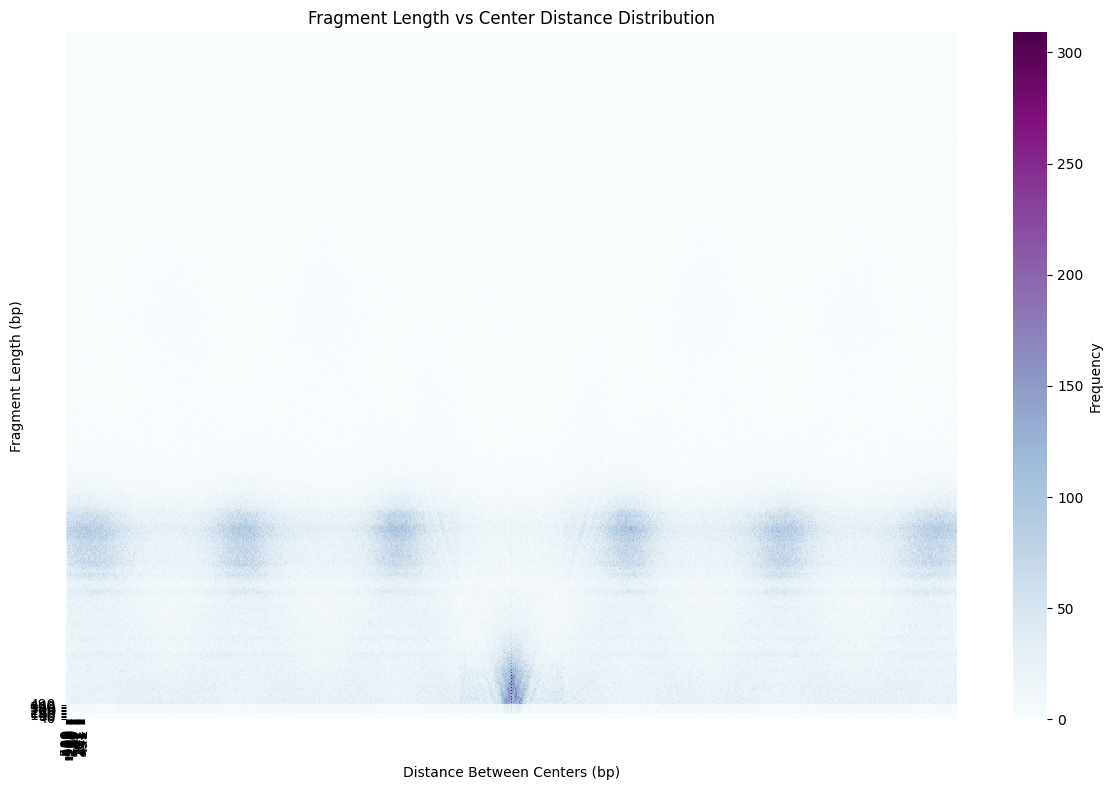

Unique coordinate pairs: 280653


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

def generate_fragment_heatmap(input_file):
    """Generate heatmap of fragment length vs delta center distribution."""

    # Initialize counter for coordinate pairs
    coord_counts = Counter()

    # Process each line in input file
    with open(input_file, 'r') as file:
        for line in file:
            fields = line.strip().split('\t')

            # Calculate center distance between fragments
            center1 = (int(fields[2]) + int(fields[3])) / 2
            center2 = (int(fields[8]) + int(fields[9])) / 2
            delta_center = int(center2 - center1)

            # Calculate fragment length
            frag_length = int(fields[9]) - int(fields[8])

            # Count coordinate pairs
            coord_counts[(delta_center, frag_length)] += 1

    # Prepare sorted unique values for axes
    delta_centers = sorted({dc for dc, fl in coord_counts})
    frag_lengths = sorted({fl for dc, fl in coord_counts})

    # Initialize and populate heatmap matrix
    heatmap = np.zeros((len(frag_lengths), len(delta_centers)))
    for i, fl in enumerate(frag_lengths):
        for j, dc in enumerate(delta_centers):
            heatmap[i, j] = coord_counts.get((dc, fl), 0)

    # Generate heatmap visualization
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        heatmap,
        cmap='BuPu',
        xticklabels=delta_centers[::50],  # Show every 50th label
        yticklabels=frag_lengths[::50],
        cbar_kws={'label': 'Frequency'}
    )

    # Configure plot appearance
    plt.gca().invert_yaxis()
    plt.title('Fragment Length vs Center Distance Distribution')
    plt.xlabel('Distance Between Centers (bp)')
    plt.ylabel('Fragment Length (bp)')
    plt.tight_layout()
    plt.show()

    print(f"Unique coordinate pairs: {len(coord_counts)}")

# Example usage
generate_fragment_heatmap("mapped.bed")